In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import shutil

# Tạo thư mục chính cho HAM10000
BASE_DRIVE = '/content/drive/MyDrive/HAM10000'
os.makedirs(BASE_DRIVE, exist_ok=True)

print("✅ Drive đã mount!")
print(f"Thư mục lưu dataset: {BASE_DRIVE}")

Mounted at /content/drive
✅ Drive đã mount!
Thư mục lưu dataset: /content/drive/MyDrive/HAM10000


In [ ]:
# Cài Kaggle
!pip install -q kaggle

# Copy kaggle.json (bạn phải upload kaggle.json vào folder này trước)
!mkdir -p ~/.kaggle
!cp "/content/drive/MyDrive/Kaggle/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API đã sẵn sàng!")

cp: cannot stat '/content/drive/MyDrive/Kaggle/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API đã sẵn sàng!


In [ ]:
# Tải dataset HAM10000 (phiên bản phổ biến và đầy đủ nhất)
dataset_path = f"{BASE_DRIVE}/raw"

if not os.path.exists(dataset_path) or len(os.listdir(dataset_path)) < 5:
    print("Đang tải HAM10000 dataset từ Kaggle...")
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p {BASE_DRIVE}

    zip_file = f"{BASE_DRIVE}/skin-cancer-mnist-ham10000.zip"
    print("Đang giải nén...")
    !unzip -q {zip_file} -d {dataset_path}
    print("✅ Tải và giải nén hoàn tất!")
else:
    print("✅ Dataset HAM10000 đã tồn tại trong Drive.")

Đang tải HAM10000 dataset từ Kaggle...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:21<00:00, 68.8MB/s]

Đang giải nén...
✅ Tải và giải nén hoàn tất!


In [ ]:
# Đường dẫn sau khi unzip
ham_dir = f"{BASE_DRIVE}/raw"

print("Các file/folder chính trong dataset:")
!ls {ham_dir}

# Đọc file metadata
metadata_path = f"{ham_dir}/HAM10000_metadata.csv"
if os.path.exists(metadata_path):
    df = pd.read_csv(metadata_path)
    print(f"\nDataset có {len(df)} ảnh")
    print("\nCác cột trong metadata:")
    print(df.columns.tolist())
    display(df.head())
else:
    print("Không tìm thấy file HAM10000_metadata.csv")

Các file/folder chính trong dataset:
ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv

Dataset có 10015 ảnh

Các cột trong metadata:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


/tmp/ipykernel_6567/1548490866.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


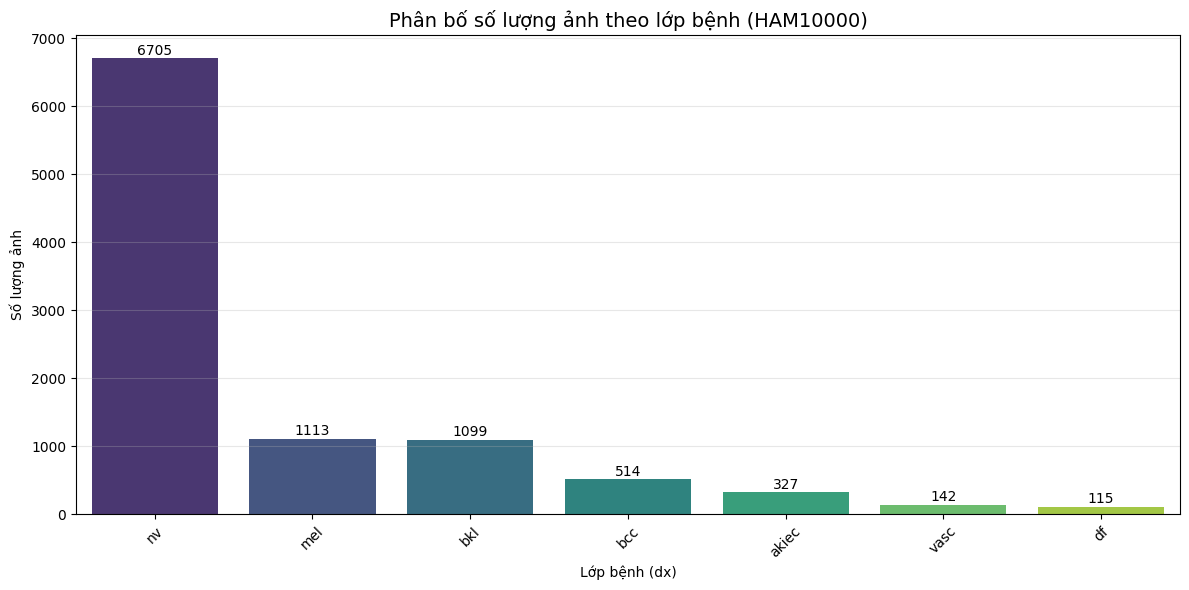


=== Bảng thống kê số lượng theo class ===
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Tổng số ảnh: 10015
Số class: 7


In [ ]:
# Đếm số lượng theo class
class_counts = df['dx'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Phân bố số lượng ảnh theo lớp bệnh (HAM10000)', fontsize=14)
plt.xlabel('Lớp bệnh (dx)')
plt.ylabel('Số lượng ảnh')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Hiển thị số liệu trên cột
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# In bảng chi tiết
print("\n=== Bảng thống kê số lượng theo class ===")
print(class_counts)
print(f"\nTổng số ảnh: {len(df)}")
print(f"Số class: {df['dx'].nunique()}")

/tmp/ipykernel_6567/2446790196.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', ax=axes[0], palette='Set2')


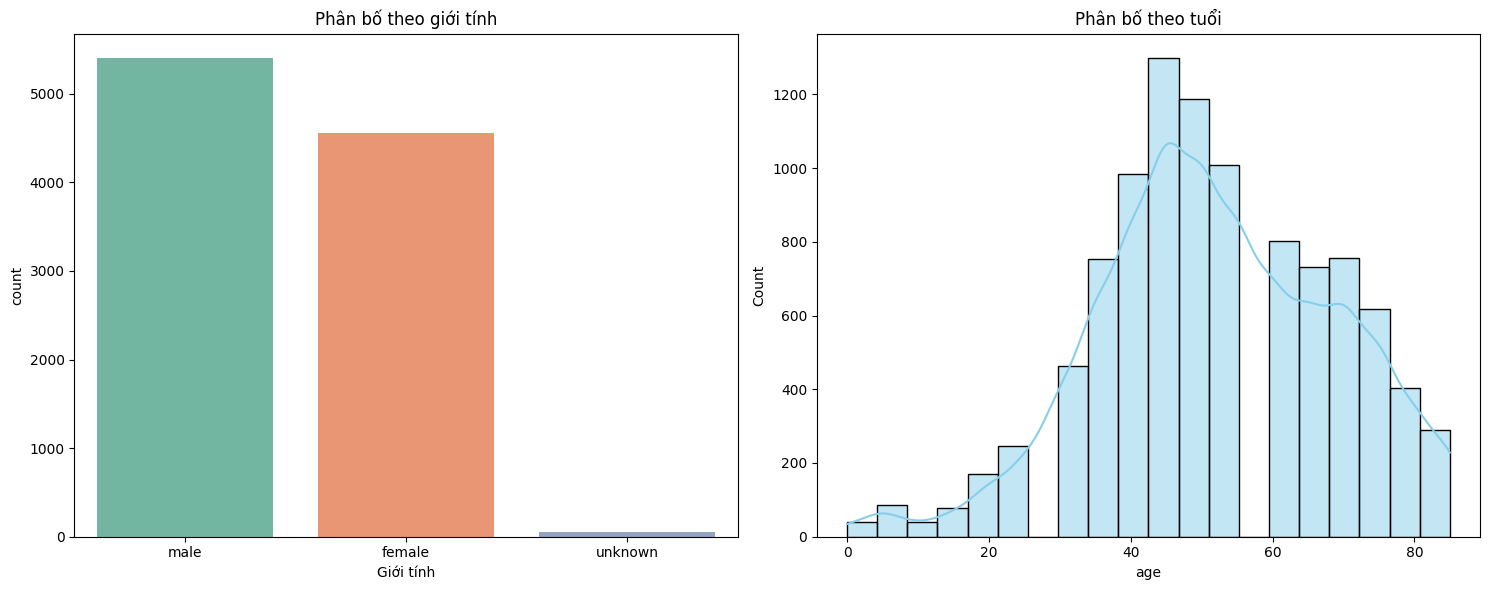


Số lượng theo class và giới tính:
sex    female  male  unknown
dx                          
akiec     106   221        0
bcc       197   317        0
bkl       463   626       10
df         52    63        0
mel       424   689        0
nv       3237  3421       47
vasc       73    69        0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Theo giới tính
sns.countplot(data=df, x='sex', ax=axes[0], palette='Set2')
axes[0].set_title('Phân bố theo giới tính')
axes[0].set_xlabel('Giới tính')

# Theo tuổi
sns.histplot(data=df, x='age', bins=20, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Phân bố theo tuổi')

plt.tight_layout()
plt.show()

# Thống kê chi tiết theo class và giới tính
print("\nSố lượng theo class và giới tính:")
print(pd.crosstab(df['dx'], df['sex']))

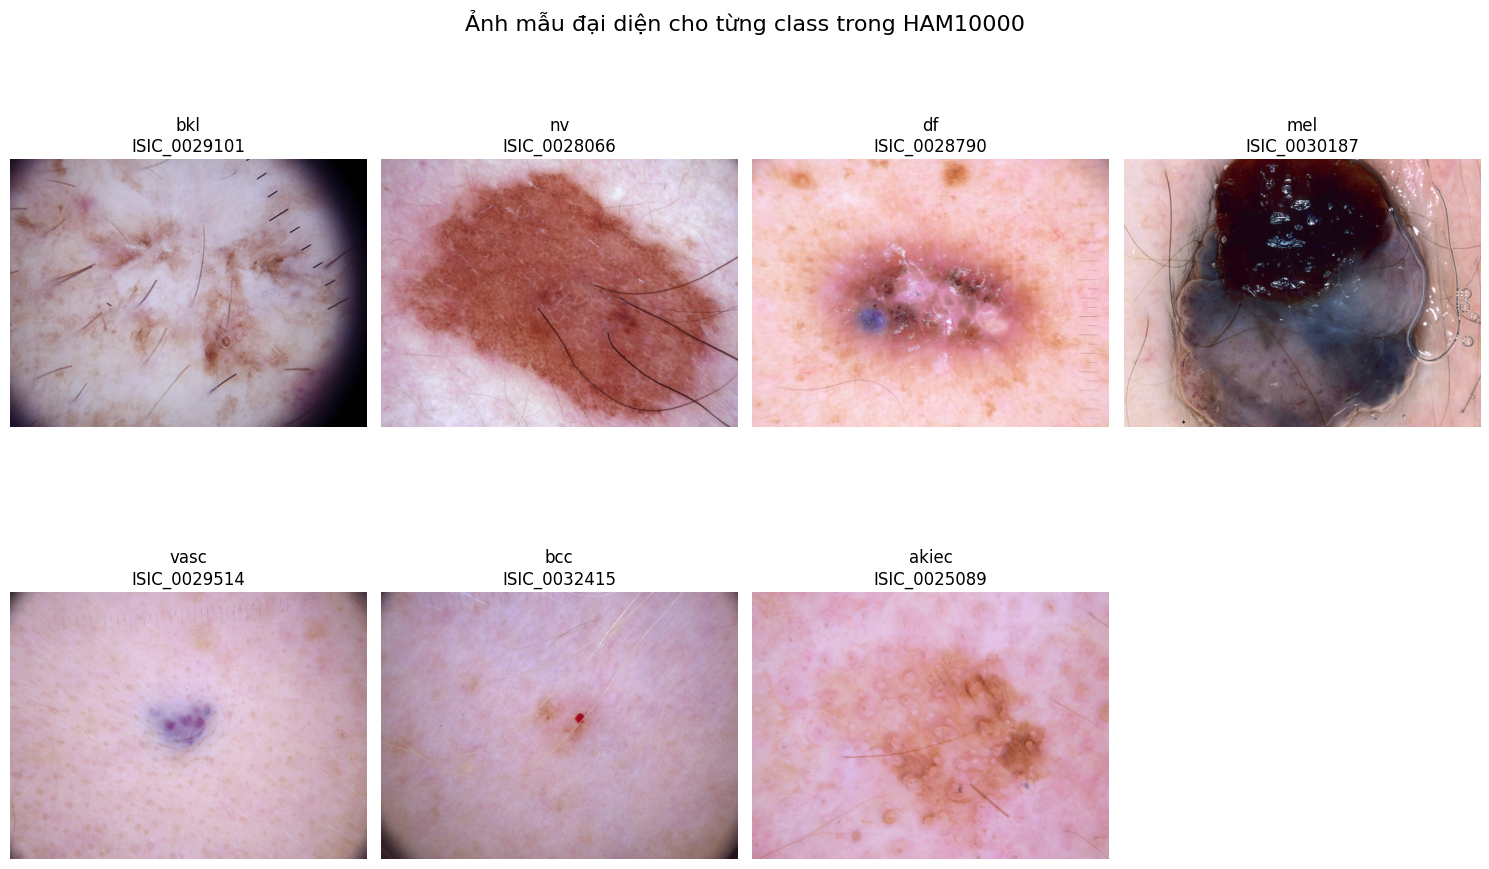

In [ ]:
import random

# Đường dẫn thư mục chứa ảnh
image_dir = f"{ham_dir}/HAM10000_images_part_1"   # Thường có 2 part

# Nếu có part 2 thì gộp
if os.path.exists(f"{ham_dir}/HAM10000_images_part_2"):
    image_dir2 = f"{ham_dir}/HAM10000_images_part_2"

# Lấy mẫu 7 class
classes = df['dx'].unique()

plt.figure(figsize=(15, 10))
for i, cls in enumerate(classes[:7]):   # Hiển thị 7 class
    # Lấy 1 ảnh ngẫu nhiên thuộc class này
    sample = df[df['dx'] == cls].sample(1).iloc[0]
    img_id = sample['image_id']

    # Tìm ảnh (có thể ở part 1 hoặc part 2)
    img_path = f"{ham_dir}/HAM10000_images_part_1/{img_id}.jpg"
    if not os.path.exists(img_path):
        img_path = f"{ham_dir}/HAM10000_images_part_2/{img_id}.jpg"

    if os.path.exists(img_path):
        img = plt.imread(img_path)
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(f"{cls}\n{img_id}")
        plt.axis('off')

plt.suptitle('Ảnh mẫu đại diện cho từng class trong HAM10000', fontsize=16)
plt.tight_layout()
plt.show()